Loading CIFAR-10...
Loaded: data_batch_1
Loaded: data_batch_2
Loaded: data_batch_3
Loaded: data_batch_4
Loaded: data_batch_5
Data shape: (50000, 3072)
Image shape: (50000, 32, 32, 3)
Processing data...


C:\Users\momo\AppData\Local\Temp\ipykernel_11752\794280291.py:23: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f, encoding='latin1')


Done!


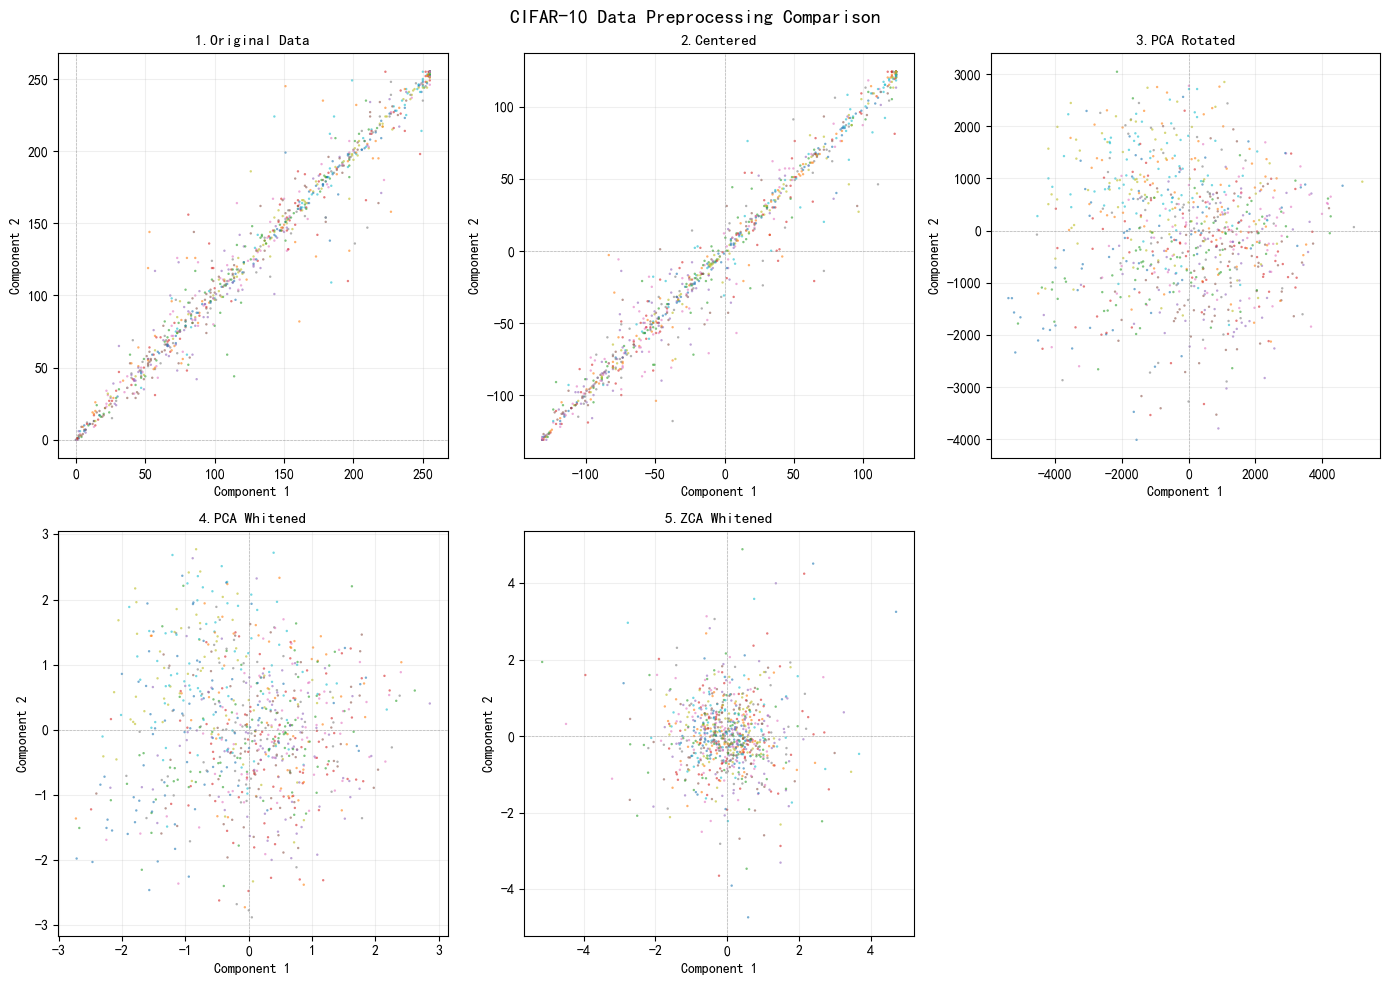

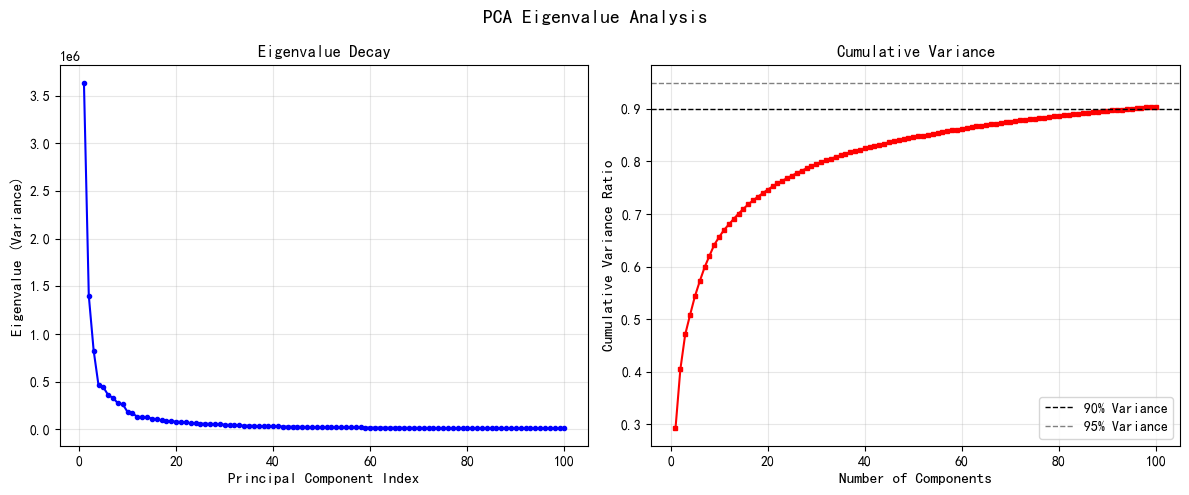

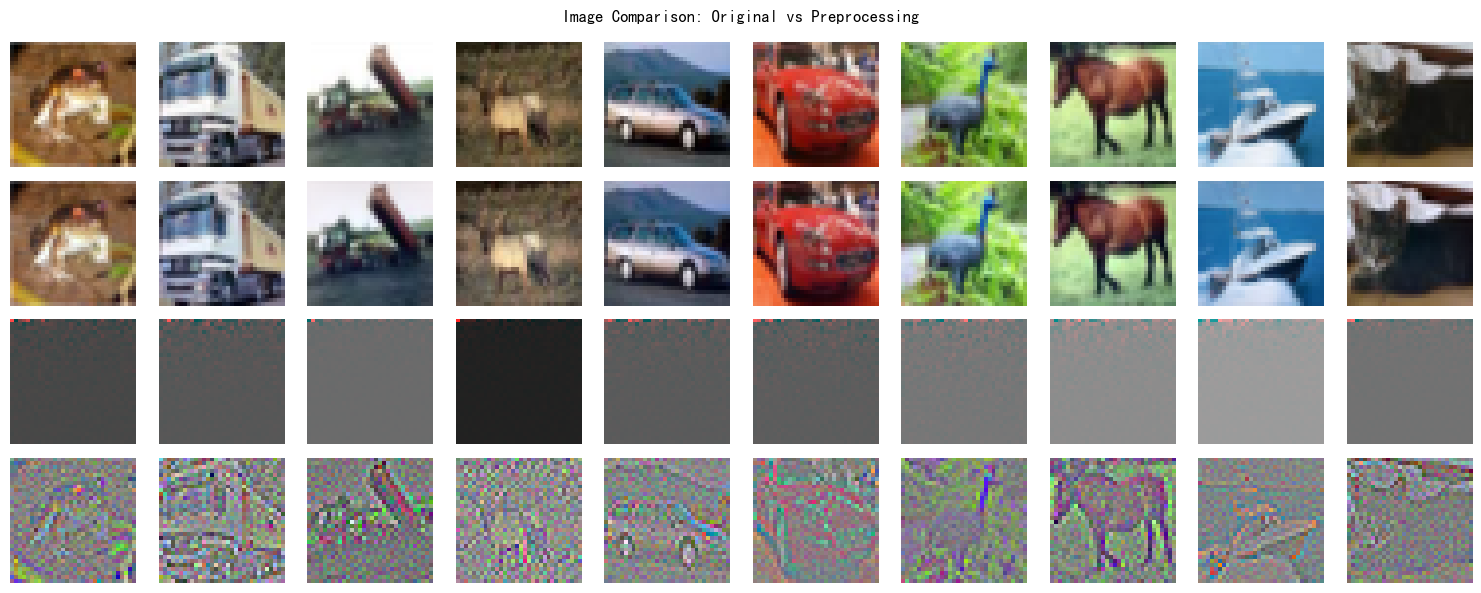

Dim 10: MSE = 1393.8195
Dim 50: MSE = 624.8454
Dim 100: MSE = 387.4022
Dim 200: MSE = 205.5213
Dim 500: MSE = 56.4578
Dim 1000: MSE = 10.0971
Dim 2000: MSE = 0.2707


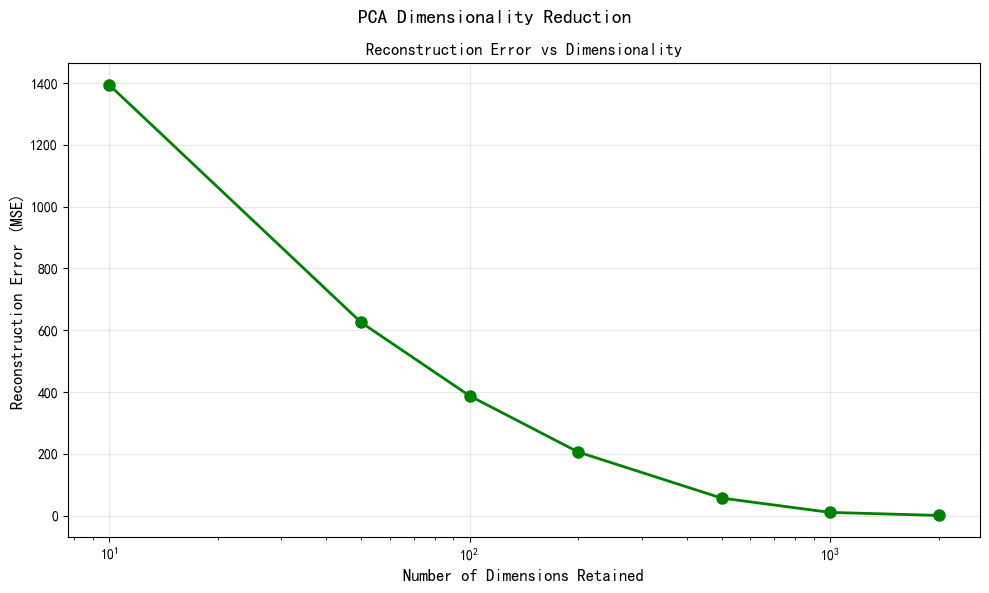


Statistical Summary

[Original]
  Shape: (5000, 3072)
  Mean (first 5 dims): [131.4542 130.7926 131.6824 132.6776 133.6552]
  Var (first 5 dims): [5508.52990236 5351.31838524 5304.20833024 5242.33405824 5229.34191296]

[Centered]
  Shape: (5000, 3072)
  Mean (first 5 dims): [-6.63362698e-15  6.91670721e-14 -1.54955160e-14  1.24430244e-14
 -1.30967237e-14]
  Var (first 5 dims): [5508.52990236 5351.31838524 5304.20833024 5242.33405824 5229.34191296]

[PCA Rotated]
  Shape: (5000, 3072)
  Mean (first 5 dims): [ 1.57342583e-14  4.94310370e-14  1.65300662e-14  5.00222086e-16
 -2.00770955e-14]
  Var (first 5 dims): [3635711.39508929 1400410.65248558  826402.70676767  462478.06698408
  441391.9699842 ]

[PCA Whitened]
  Shape: (5000, 3072)
  Mean (first 5 dims): [ 7.46069873e-18  3.12416759e-17  1.85185201e-17  1.10578213e-17
 -1.43662859e-17]
  Var (first 5 dims): [1. 1. 1. 1. 1.]

[ZCA Whitened]
  Shape: (5000, 3072)
  Mean (first 5 dims): [ 1.63341562e-15  1.29638744e-14 -6.80214773e-15 -

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 1. 加载本地CIFAR-10数据集
# ============================================
data_path = r"C:\Users\momo\Desktop\documentations\vscode\0329practice\cifar-10-data\cifar-10-batches-py"

def load_cifar10(data_path):
    """加载CIFAR-10数据集"""
    X_list = []
    y_list = []
    
    for i in range(1, 6):
        batch_file = os.path.join(data_path, f'data_batch_{i}')
        with open(batch_file, 'rb') as f:
            batch = pickle.load(f, encoding='latin1')
            X_list.append(batch['data'])
            y_list.append(batch['labels'])
        print(f'Loaded: data_batch_{i}')
    
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    X_images = X.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    
    return X, X_images, y

print('Loading CIFAR-10...')
X_raw, X_images, y = load_cifar10(data_path)
print(f'Data shape: {X_raw.shape}')
print(f'Image shape: {X_images.shape}')

# 使用5000个样本
num_samples = 5000
X_raw = X_raw[:num_samples]
X_images = X_images[:num_samples]
y = y[:num_samples]

# ============================================
# 2. 预处理函数
# ============================================
def center_data(X):
    X_centered = X - np.mean(X, axis=0)
    return X_centered

def pca_decorrelate(X):
    X_centered = X - np.mean(X, axis=0)
    cov = np.dot(X_centered.T, X_centered) / X_centered.shape[0]
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]
    eigvals = eigvals[idx]
    X_rotated = np.dot(X_centered, eigvecs)
    return X_rotated, eigvecs, eigvals

def pca_whiten(X, eps=1e-5):
    X_centered = X - np.mean(X, axis=0)
    cov = np.dot(X_centered.T, X_centered) / X_centered.shape[0]
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    X_rotated = np.dot(X_centered, eigvecs)
    X_white = X_rotated / np.sqrt(eigvals + eps)
    return X_white, eigvecs, eigvals

def zca_whiten(X, eps=1e-5):
    X_centered = X - np.mean(X, axis=0)
    cov = np.dot(X_centered.T, X_centered) / X_centered.shape[0]
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    X_pca_white = np.dot(X_centered, eigvecs) / np.sqrt(eigvals + eps)
    X_zca = np.dot(X_pca_white, eigvecs.T)
    return X_zca, eigvecs, eigvals

# ============================================
# 3. 应用预处理
# ============================================
print('Processing data...')
X_cent = center_data(X_raw)
X_pca, eigvecs, eigvals = pca_decorrelate(X_raw)
X_pca_white, _, _ = pca_whiten(X_raw)
X_zca, _, _ = zca_whiten(X_raw)
print('Done!')

# ============================================
# 4. 图1: 2D散点图对比
# ============================================
fig1, axes1 = plt.subplots(2, 3, figsize=(14, 10))
fig1.suptitle('CIFAR-10 Data Preprocessing Comparison', fontsize=14, fontweight='bold')

def scatter_2d(ax, data, title, sample_n=800):
    idx = np.random.choice(len(data), min(sample_n, len(data)), replace=False)
    ax.scatter(data[idx, 0], data[idx, 1], c=y[idx], cmap='tab10', s=3, alpha=0.6, edgecolors='none')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_xlabel('Component 1', fontsize=10)
    ax.set_ylabel('Component 2', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.2)

scatter_2d(axes1[0,0], X_raw, '1.Original Data')
scatter_2d(axes1[0,1], X_cent, '2.Centered')
scatter_2d(axes1[0,2], X_pca, '3.PCA Rotated')
scatter_2d(axes1[1,0], X_pca_white, '4.PCA Whitened')
scatter_2d(axes1[1,1], X_zca, '5.ZCA Whitened')

axes1[1,2].axis('off')
plt.tight_layout()
plt.savefig('preprocessing_2d.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 5. 图2: 特征值分布
# ============================================
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('PCA Eigenvalue Analysis', fontsize=14, fontweight='bold')

n_show = min(100, len(eigvals))
axes2[0].plot(range(1, n_show+1), eigvals[:n_show], 'b-', linewidth=1.5, marker='o', markersize=3)
axes2[0].set_xlabel('Principal Component Index', fontsize=11)
axes2[0].set_ylabel('Eigenvalue (Variance)', fontsize=11)
axes2[0].set_title('Eigenvalue Decay', fontsize=12)
axes2[0].grid(True, alpha=0.3)

cumsum = np.cumsum(eigvals) / np.sum(eigvals)
axes2[1].plot(range(1, n_show+1), cumsum[:n_show], 'r-', linewidth=1.5, marker='s', markersize=3)
axes2[1].axhline(y=0.9, color='k', linestyle='--', linewidth=1, label='90% Variance')
axes2[1].axhline(y=0.95, color='gray', linestyle='--', linewidth=1, label='95% Variance')
axes2[1].set_xlabel('Number of Components', fontsize=11)
axes2[1].set_ylabel('Cumulative Variance Ratio', fontsize=11)
axes2[1].set_title('Cumulative Variance', fontsize=12)
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eigenvalue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 6. 图3: 图像对比
# ============================================
def normalize_img(data):
    dmin, dmax = np.min(data), np.max(data)
    if dmax - dmin < 1e-10:
        return np.zeros_like(data)
    return ((data - dmin) / (dmax - dmin) * 255).astype(np.uint8)

fig3, axes3 = plt.subplots(4, 10, figsize=(15, 6))
fig3.suptitle('Image Comparison: Original vs Preprocessing', fontsize=12, fontweight='bold')

for i in range(10):
    # Original
    axes3[0,i].imshow(X_images[i])
    axes3[0,i].axis('off')
    if i == 0:
        axes3[0,i].set_ylabel('Original', fontsize=9, rotation=0, ha='right', va='center')
    
    # Centered
    img_cent = X_cent[i].reshape(3,32,32).transpose(1,2,0)
    axes3[1,i].imshow(normalize_img(img_cent))
    axes3[1,i].axis('off')
    if i == 0:
        axes3[1,i].set_ylabel('Centered', fontsize=9, rotation=0, ha='right', va='center')
    
    # PCA Rotated
    img_pca = X_pca[i].reshape(3,32,32).transpose(1,2,0)
    axes3[2,i].imshow(normalize_img(img_pca))
    axes3[2,i].axis('off')
    if i == 0:
        axes3[2,i].set_ylabel('PCA Rotated', fontsize=9, rotation=0, ha='right', va='center')
    
    # ZCA Whitened
    img_zca = X_zca[i].reshape(3,32,32).transpose(1,2,0)
    axes3[3,i].imshow(normalize_img(img_zca))
    axes3[3,i].axis('off')
    if i == 0:
        axes3[3,i].set_ylabel('ZCA White', fontsize=9, rotation=0, ha='right', va='center')

plt.tight_layout()
plt.savefig('image_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 7. 图4: 降维效果
# ============================================
fig4, ax4 = plt.subplots(figsize=(10, 6))
fig4.suptitle('PCA Dimensionality Reduction', fontsize=14, fontweight='bold')

dims = [10, 50, 100, 200, 500, 1000, 2000]
errors = []

X_cent_all = X_raw - np.mean(X_raw, axis=0)

for d in dims:
    if d >= len(eigvals):
        continue
    X_reduced = np.dot(X_cent_all, eigvecs[:, :d])
    X_recon = np.dot(X_reduced, eigvecs[:, :d].T)
    mse = np.mean((X_cent_all - X_recon) ** 2)
    errors.append(mse)
    print(f'Dim {d}: MSE = {mse:.4f}')

ax4.plot(dims[:len(errors)], errors, 'g-o', linewidth=2, markersize=8)
ax4.set_xlabel('Number of Dimensions Retained', fontsize=12)
ax4.set_ylabel('Reconstruction Error (MSE)', fontsize=12)
ax4.set_title('Reconstruction Error vs Dimensionality', fontsize=12)
ax4.set_xscale('log')
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dimension_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 8. 打印统计信息
# ============================================
print('\n' + '='*60)
print('Statistical Summary')
print('='*60)

def print_stats(name, data):
    mean_val = np.mean(data[:, :5], axis=0)
    var_val = np.var(data[:, :5], axis=0)
    print(f'\n[{name}]')
    print(f'  Shape: {data.shape}')
    print(f'  Mean (first 5 dims): {mean_val[:5]}')
    print(f'  Var (first 5 dims): {var_val[:5]}')

print_stats('Original', X_raw)
print_stats('Centered', X_cent)
print_stats('PCA Rotated', X_pca)
print_stats('PCA Whitened', X_pca_white)
print_stats('ZCA Whitened', X_zca)

print('\n' + '='*60)
print('Key Observations')
print('='*60)
print('''
1. Original:     Non-zero mean, correlated features
2. Centered:     Zero mean, still correlated
3. PCA Rotated:  Zero mean, uncorrelated (diagonal covariance)
4. PCA Whitened: Zero mean, uncorrelated, unit variance (spherical)
5. ZCA Whitened: Same as PCA whitened but rotated back to original space
''')